# 🤗 Hugging Face Pipelines – Multimodal Tasks

This notebook demonstrates the use of Hugging Face Transformers pipelines for performing a variety of AI tasks across different domains.

## 🚀 Objectives
- Understand how to use prebuilt pipelines for rapid prototyping
- Explore NLP, Computer Vision, and Audio tasks
- Run inference on GPU (Colab) for efficiency

---

## 📌 Tasks Covered

### 🧠 Natural Language Processing (NLP)
- Text Generation
- Text Summarization
- Translation
- Sentiment Analysis
- Text Classification

### 🖼️ Computer Vision
- Text- to -Image


### 🔊 Audio Processing
- Text-to-Speech

---

## ⚙️ Key Concepts
- Hugging Face `pipeline()` API
- Model & tokenizer abstraction
- GPU acceleration in Colab
- Handling different modalities with a unified interface

---

## 🧩 Why This Matters
Hugging Face pipelines allow rapid experimentation with state-of-the-art models without building everything from scratch. This is essential for:
- Prototyping ML applications
- Building AI demos quickly
- Understanding model capabilities across domains

---

## 🛠️ Tech Stack
- Python
- Transformers (Hugging Face)
- PyTorch
- Google Colab (GPU)

---

## 📎 Notes
- Some pipeline tasks may vary depending on the installed Transformers version
- Direct model loading (`AutoModel`) is used when pipeline APIs are unavailable

---

In [1]:
# I've had to add in this pip install since making the video, as HuggingFace made a breaking change!

!pip install -q --upgrade transformers==4.56.2 diffusers==0.32.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.5 MB/s eta 0:00:00


In [2]:
from huggingface_hub import login
from google.colab import userdata


hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

text_encoder_2/model.fp16.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/4 [00:00<?, ?it/s]

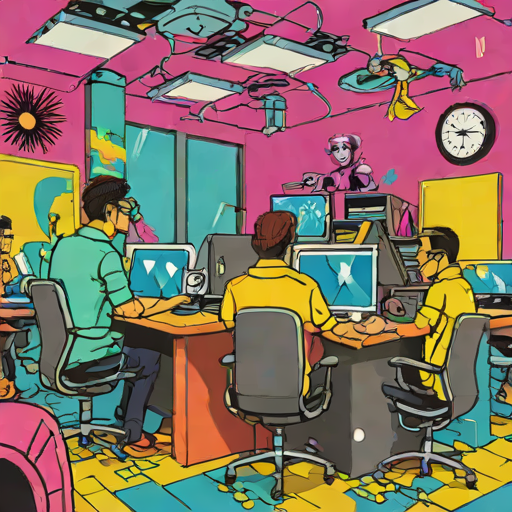

In [3]:
from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")
prompt = "A room  of software  engineers working at a AI engineering company in a vibrant pop-art style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)


In [6]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [1]:
!pip install -q --upgrade datasets==3.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 11.1 MB/s eta 0:00:00


In [2]:
import torch
import subprocess

print("=== TORCH GPU INFO ===")
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Count:", torch.cuda.device_count())
    print("CUDA Version:", torch.version.cuda)
    print("Current Device:", torch.cuda.current_device())
    print("Device Capability:", torch.cuda.get_device_capability(0))
else:
    print("No GPU detected")

print("\n=== NVIDIA-SMI ===")
try:
    print(subprocess.check_output(["nvidia-smi"]).decode())
except:
    print("nvidia-smi not available")

=== TORCH GPU INFO ===
GPU Available: True
GPU Name: Tesla T4
GPU Count: 1
CUDA Version: 12.8
Current Device: 0
Device Capability: (7, 5)

=== NVIDIA-SMI ===
Thu Apr 16 12:02:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             13W /   70W |       3MiB /  15360MiB |      

In [3]:
import torch
from google.colab import userdata
from huggingface_hub import login
from transformers import pipeline
from diffusers import DiffusionPipeline
from datasets import load_dataset
import soundfile as sf
from IPython.display import Audio

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
hf_token = userdata.get('HF_TOKEN')
if hf_token and hf_token.startswith("hf_"):
  print("HF key looks good so far")
else:
  print("HF key is not set - please click the key in the left sidebar")
login(hf_token, add_to_git_credential=True)

HF key looks good so far


In [5]:

my_simple_sentiment_analyzer = pipeline("sentiment-analysis", device="cuda")
result = my_simple_sentiment_analyzer("I'm super excited to finetune a LLM!")
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.998161256313324}]


In [6]:
result = my_simple_sentiment_analyzer("I should be more excited to learn about QLoRa!")
print(result)

[{'label': 'POSITIVE', 'score': 0.9614280462265015}]


In [7]:

better_sentiment = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device="cuda")
result = better_sentiment("I should be more excited to be on the way to LLM mastery!!")
print(result)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': '3 stars', 'score': 0.39448031783103943}]


In [8]:
# Named Entity Recognition

ner = pipeline("ner", device="cuda")
result = ner("Its Interesting to learn about Logic/reasoning models by reading an article by AndrAndrej Karpathy")
for entity in result:
  print(entity)

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

{'entity': 'I-PER', 'score': np.float32(0.9991074), 'index': 16, 'word': 'And', 'start': 79, 'end': 82}
{'entity': 'I-PER', 'score': np.float32(0.9402225), 'index': 17, 'word': '##r', 'start': 82, 'end': 83}
{'entity': 'I-PER', 'score': np.float32(0.964988), 'index': 18, 'word': '##A', 'start': 83, 'end': 84}
{'entity': 'I-PER', 'score': np.float32(0.992926), 'index': 19, 'word': '##nd', 'start': 84, 'end': 86}
{'entity': 'I-PER', 'score': np.float32(0.97275066), 'index': 20, 'word': '##re', 'start': 86, 'end': 88}
{'entity': 'I-PER', 'score': np.float32(0.99843794), 'index': 21, 'word': '##j', 'start': 88, 'end': 89}
{'entity': 'I-PER', 'score': np.float32(0.99975985), 'index': 22, 'word': 'Ka', 'start': 90, 'end': 92}
{'entity': 'I-PER', 'score': np.float32(0.99700433), 'index': 23, 'word': '##rp', 'start': 92, 'end': 94}
{'entity': 'I-PER', 'score': np.float32(0.9761377), 'index': 24, 'word': '##athy', 'start': 94, 'end': 98}


In [9]:
# Question Answering with Context

question="What are Hugging Face pipelines?"
context="Pipelines are a high level API for inference of LLMs with common tasks"

question_answerer = pipeline("question-answering", device="cuda")
result = question_answerer(question=question, context=context)
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'score': 0.24576981365680695, 'start': 35, 'end': 70, 'answer': 'inference of LLMs with common tasks'}


In [16]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


model_name = "google/flan-t5-small"


tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")

text = """
The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing (NLP).
It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering, among others.
It's an extremely popular library that's widely used by the open-source data science community.
It lowers the barrier to entry into the field by providing Data Scientists with a productive, convenient way to work with transformer models.
"""

prompt = "Summarize this text:\n" + text

inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda")
outputs = model.generate(**inputs, max_new_tokens=50, min_new_tokens=25, do_sample=False)

summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(summary)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Hugging Face is a powerful tool for data science. It's a powerful tool for data science. It's a powerful tool for data science.


In [21]:
model_name = "Helsinki-NLP/opus-mt-en-de"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")

text = "The Data Scientists were truly amazed by the power and simplicity of the HuggingFace pipeline API."

inputs = tokenizer(text, return_tensors="pt", truncation=True).to("cuda")
outputs = model.generate(**inputs, max_new_tokens=100)

translation = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(translation)

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Die Data Scientists waren wirklich erstaunt über die Kraft und Einfachheit der HuggingFace Pipeline API.


In [19]:
# Classification

classifier = pipeline("zero-shot-classification", device="cuda")
result = classifier("Hugging Face's Transformers library is amazing!", candidate_labels=["technology", "sports", "politics"])
print(result)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'sequence': "Hugging Face's Transformers library is amazing!", 'labels': ['technology', 'sports', 'politics'], 'scores': [0.9493839740753174, 0.03225007280707359, 0.018365919589996338]}


In [14]:
# Text Generation

generator = pipeline("text-generation", device="cuda")
result = generator("If there's one thing I want you to remember about using HuggingFace pipelines, it's")
print(result[0]['generated_text'])

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


If there's one thing I want you to remember about using HuggingFace pipelines, it's that your data is a part of it. While your data is important, it's really more important if you're going to be able to leverage that data and make your application stand out from the crowd.

Now, let's look at the more complicated data.

What is a HuggingFace?

The HuggingFace is an open source project called HuggingFace. It's meant to be used in conjunction with other projects, and to make your application stand out from the crowd.

First, let's look at the code.

ng.render

import { Component } from '@angular/core'; import { Handle } from './handle'; export class Handle extends Component { constructor() { super(Handle, { this.handle()}); } }

First, let's look at that code. In this file, we have Handle's constructor. We also have the constructor method that takes two arguments: the handle object and the handle function.

First, we need to make sure that Handle is a handle. Handle is a handle which is 

In [18]:
# Audio Generation

from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch
from IPython.display import Audio

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = synthesiser("Hi to an curious deep learning Engineer learning about LLm's", forward_params={"speaker_embeddings": speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

SpeechT5ForTextToSpeech LOAD REPORT from: microsoft/speecht5_tts
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
speecht5.encoder.prenet.encode_positions.pe | UNEXPECTED |  | 
speecht5.decoder.prenet.encode_positions.pe | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/158 [00:00<?, ?it/s]